<a href="https://colab.research.google.com/github/kaushikpatriot/ML-Projects/blob/main/Logistic_and_Softmax_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Logistic Regression

###The idea
Supervised learning algorithm for binary classification
###Training Data
Features - (n,m)
Label - (n,) - with 0 and 1 as labels
###Model
$log(odds) = \frac {P(y=1|x)}{P(y=0|x)}$<br>
$z = w^Tx$ <br>
$\sigma(z) = \frac{1}{1+e^{-z}}$<br>
$\hat{y} = 1 if \sigma(z) > threshold $<br>
$\hat{y} = 0 if \sigma(z) <= threshold $
###Loss - Binary Cross Entropy
**no regularization**<br>
$J(w) = - \sum y_{i}log(\hat{y_i)}+(1-y_i)log(1-\hat{y_i})$

**with L1 regularization**<br>
$J(w) = - \sum y_{i}log(\hat{y_i)}+(1-y_i)log(1-\hat{y_i}) + \frac{\lambda}{2} |w|$

**with L2 regularization**<br>
$J(w) = - \sum y_{i}log(\hat{y_i)}+(1-y_i)log(1-\hat{y_i}) + \frac{\lambda}{2} ||w||^2$

###Optimization
$\frac {\partial J(w)}{\partial w} = X^T(\hat{y}-y) + \lambda w$ <br>
$w_{old} = w_{new} - \alpha \frac {\partial J(w)}{\partial w}$


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
import itertools
import functools
def get_combinations(X, deg):
  return itertools.combinations_with_replacement(X, deg)

def compute_features(items):
  return functools.reduce(lambda x, y: x*y, items)

def polynomial_transform(X, degrees):
  if X.ndim == 1:
    X = np.expand_dims(X,-1)

  X_t = X.T
  features = [np.ones(X.shape[0])]

  for deg in range(1, degrees+1):
    for items in get_combinations(X_t,deg):
      features.append(compute_features(items))

  return np.asarray(features).T


In [ ]:
def linear_combination(X,w):
  return X@w

def sigmoid(X,w):
  z = linear_combination(X,w)
  return 1/(1+np.exp(-z))

def predict(X,w, threshold):
  z = linear_combination(X,w)
  sig = sigmoid(z)
  np.where(sig > threshold, 1, 0)

def loss(X,w,y, l1=0, l2=0):
  y_hat = sigmoid(X,w)
  loss = -1*np.sum(y*np.log(y_hat)+(1-y)*np.log(1-y_hat)) + 0.5*l1*np.sum(np.abs(w)) + 0.5*l2*(w.T@w)
  return loss

def calc_grad(X,w,y):
  return X.T@(sigmoid(X,w) - y)

def update_weight(w, grad, lr):
  return w - lr*grad

def gd(X,y, epochs=100, lr=0.01, l1=0, l2=0):
  # Initialise
  w = np.zeros(X.shape[1])
  w_all = []
  err_all = []

  # Gradient descent
  for i in range(epochs):
    grad = calc_grad(X,w,y)
    w = update_weight(w, grad, lr)
    w_all.append(w)
    lss = loss(X,w,y)
    err_all.append(lss)

  return w, w_all, err_all


In [ ]:
def create_data():
  x0 = np.random.normal(1,1,50).reshape(-1,2)
  x1 = np.random.normal(-1,1,50).reshape(-1,2)
  return np.concatenate([x0,x1]), np.concatenate([np.zeros(x0.shape[0]), np.ones(x0.shape[0])])

X,y = create_data()
print(X.shape, y.shape)
X_train = polynomial_transform(X,1)


(50, 2) (50,)


(50, 3)

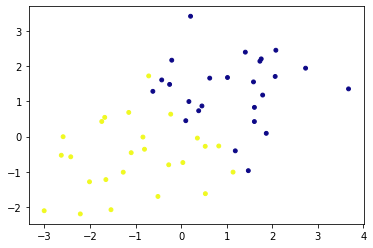

In [ ]:
plt.scatter(X[:,0],X[:,1], c=y, s = 15, cmap = 'plasma')

[ 1.02651812 -2.1867673  -2.07417949]


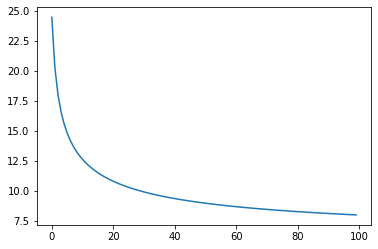

In [ ]:
w, w_all, err_all = gd(X_train,y)
e = np.arange(100)
print(w)
plt.plot(e, err_all)

##Softmax Regression

###The Idea
Supervised learning for multi-class, multi label problems. It is a generalisation of Logistic regression

###Training Data
Features - n,m
Label - n,k (after one hot encoding)

###Model
Softmax activation function<br>
$z = w^Tx + b$<br>

$P(y=c|x) = g(z_c) = \frac {e^{z_c}}{\sum e^z_i}$

###Loss - Categorical Entropy Loss
$J(W,b) = -\sum y^c log \hat{y_c}$<br>
where <br>
$\hat{y_c} = g(z_c)$


###Optimization
$\frac {\partial}{\partial w} J(W,b) = X^T(\hat{Y} - Y)$ <br>
$\frac {\partial}{\partial b} J(W,b) = (\hat{Y} - Y)$<br>
$w_{new} = w_{old} - \alpha \frac {\partial}{\partial w} J(W,b)$<br>
$b_{new} = b_{old} - \alpha \frac {\partial}{\partial b} J(W,b)$

###Evaluation
Confusion matrix, accuracy, precision, recall, F1-score

In [ ]:
import numpy as np
from keras.datasets import mnist
import matplotlib.pyplot as plt

In [ ]:
(train_X, train_y), (test_X, test_y) = mnist.load_data()

11501568/11490434 [==============================] - 0s 0us/step


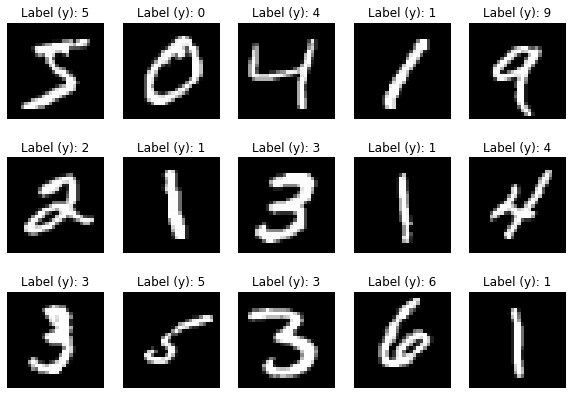

In [ ]:
fig = plt.figure(figsize=(10,7))
for i in range(15):
  ax = fig.add_subplot(3,5,i+1)
  ax.imshow(train_X[i], cmap=plt.get_cmap('gray'))
  ax.set_title('Label (y): {y}'.format(y = train_y[i]))
  plt.axis('off')

In [ ]:
X_train = train_X.reshape(train_X.shape[0],28*28)
X_test = test_X.reshape(test_X.shape[0],28*28)

In [ ]:
X_train = X_train/255
X_test = X_test/255

In [ ]:
def one_hot_encoding(y):
  #assumes class labels can be numbered in any many manner and not necessarily starting from zero
  y_un = np.unique(y)
  print(y_un)
  k = len(y_un)
  enc = np.zeros((len(y),k))
  for i in range(len(y)):
    idx = np.where(y_un == y[i])
    enc[i,idx] = 1
  print(enc)
  return enc

def linear_combo (X,w,b):
  return X@w + b

def softmax(z):
  exp = np.exp(z-np.max(z))
  sum = np.sum(exp)
  for i in range(len(z)):
    exp[i] = exp[i] / sum
  return exp

def loss(y,y_hat):
  #return -np.mean(np.log(y_hat))
  return -np.mean(np.log(y_hat[np.arange(len(y)),y]))
  #return -(1/y.shape[0])*np.sum(y*np.log(y_hat))

def fit(X,y, lr, epochs):
  #Initialise w and b
  n,m = X.shape
  c = len(np.unique(y))
  w = np.random.random((m,c))
  b = np.random.random(c)
  y_hot = one_hot_encoding(y)
  losses = []
  for i in range(epochs):
    y_hat = softmax(linear_combo(X,w,b))
    grad_w = (1/n)*X.T@(y_hat-y_hot)
    grad_b = (1/n)*np.sum(y_hat-y_hot)
    w = w - lr*grad_w
    b = b - lr*grad_b
    if i%10 == 0:
      losses.append(loss(y,y_hat))
  return w,b,losses


def predict(X,w,b):
  z = linear_combo(X,w,b)
  smax = softmax(z)
  return np.argmax(smax, axis=1)

def accuracy(y_pred, y_act):
  return np.mean(np.where(y_pred==y_act))


In [ ]:
one_hot_encoding(train_y)

[0 1 2 3 4 5 6 7 8 9]
[[0. 0. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 1. 0.]]


array([[0., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.]])

In [ ]:
w, b, l = fit(X_train, train_y, lr = 0.9,  epochs = 100)
l

[13.343833773553284,
 13.343681405991662,
 13.343529067871636,
 13.343376759196769,
 13.34322447997062,
 13.343072230196766,
 13.342920009878751,
 13.342767819020152,
 13.342615657624524,
 13.342463525695447]

In [ ]:
test_preds = predict(X_test,w,b)

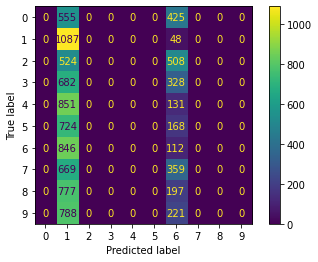

In [ ]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(test_y, test_preds)
cm_disp = ConfusionMatrixDisplay(cm)
cm_disp.plot()

In [ ]:
accuracy(test_preds, test_y)

4975.107589658049

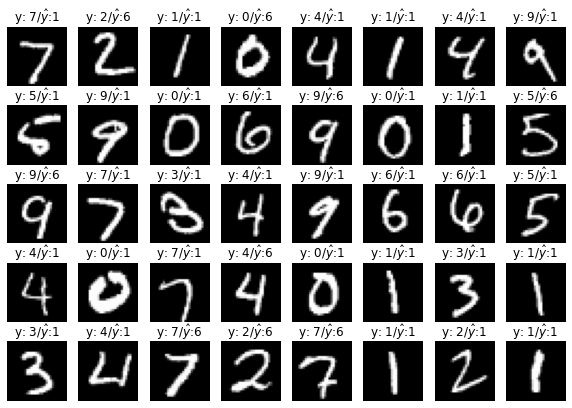

In [ ]:
#Plotting prediction
fig = plt.figure(figsize=(10,7))
for i in range(40):
  ax = fig.add_subplot(5,8,i+1)
  ax.imshow(test_X[i], cmap=plt.get_cmap('gray'))
  ax.set_title( f'y: ${test_y[i]}$/'+'$\hat{y}$:' + f'{test_preds[i]}')
  plt.axis('off')

###Practice stuff

In [ ]:
import numpy as np
def one_hot(y):
  yun = np.unique(y)
  size = len(yun)
  print(size, yun)
  enc = np.zeros((len(y),size))
  for i in range(len(y)):
      idx = np.where(yun == y[i])
      print(idx)
      enc[i, idx] = 1
  return enc

y = np.array([[4],[7],[0],[4]])
one_hot(y)


3 [0 4 7]
(array([1]),)
(array([2]),)
(array([0]),)
(array([1]),)


array([[0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 1., 0.]])